# Assignment 1

This assignment covers material from Weeks 1–4. Think of it as a spot-check: five exercises that test important analytical and visualization skills from the first part of the course.

## Formalia:

<mark>Please read the **[assignment overview page](https://github.com/suneman/socialdata2026/wiki/Assignments)** carefully before proceeding.</mark> This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

***If you fail to follow these simple instructions, it will negatively impact your grade!***

**Due date and time**: The assignment is due on Monday March 2nd, 2026 at 23:55. Hand in your files via DTU Learn. 

## Important Notes:
**All exercises use your combined SF crime dataset** (2003–present) that you built during Week 2, along with your Personal Focus Crimes. Make sure you have those ready before you start.
* **Hint**: The number of focus crimes are up to you, but choosing very few focus-crimes (1-5, let's say) feels like taking the easy way out to me, so to get top marks, you'll need 8 or more focus crimes (but it's not that more are better, 16 isn't necessarily better than 8).

Each assignment draws directly on the weekly exercises - you should be able to pull your work directly from there.

<div class="alert alert-block alert-info">
The same LLM guidance applies here as during the weekly exercises: use your LLM freely for coding, pandas syntax, and plot formatting. Do not use it for interpretation, reflection, or anything that asks for your own thinking. 
<br>  <br>
If you use and LLM to cheat, you are missing out on your education ... it will mean that you're not getting all you can out of this class ... and, more importantly, that you are literally wasting this crucial time of your DTU-journey, designed to make you smarter and ready for the world.
</div>

---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

In [61]:
df = pd.read_csv(r"merged_dataset.csv")


In [62]:
CRIME_COL = "Incident Category"
YEAR_COL  = "Incident Year"

focus_crimes = [
  'Assault',
  'Burglary',
  'Vehicle Theft',
  'Drug Offense',
  'Missing Person',
  'Disorderly Conduct',
  'Stolen Property',
  'Arson',
]
focus_crimes = [c.lower() for c in focus_crimes]

df[CRIME_COL] = df[CRIME_COL].astype(str).str.strip().str.lower()

df_focus = df[
    (df[YEAR_COL] >= 2003) & (df[YEAR_COL] <= 2025) &
    (df[CRIME_COL].isin(focus_crimes))
].copy()

assert set(df_focus[CRIME_COL].unique()) == set(focus_crimes)

In [63]:
counts = (
    df_focus
    .groupby([YEAR_COL, CRIME_COL])
    .size()
    .reset_index(name="incidents")
)

wide = (
    counts
    .pivot(index=YEAR_COL, columns=CRIME_COL, values="incidents")
    .fillna(0)
    .sort_index()
)

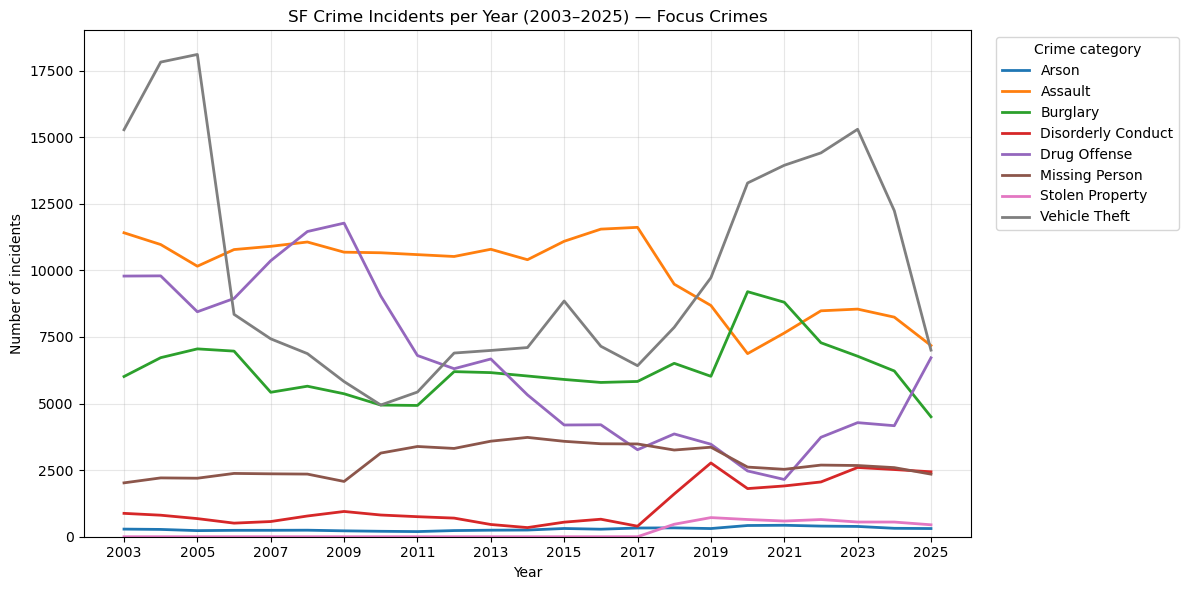

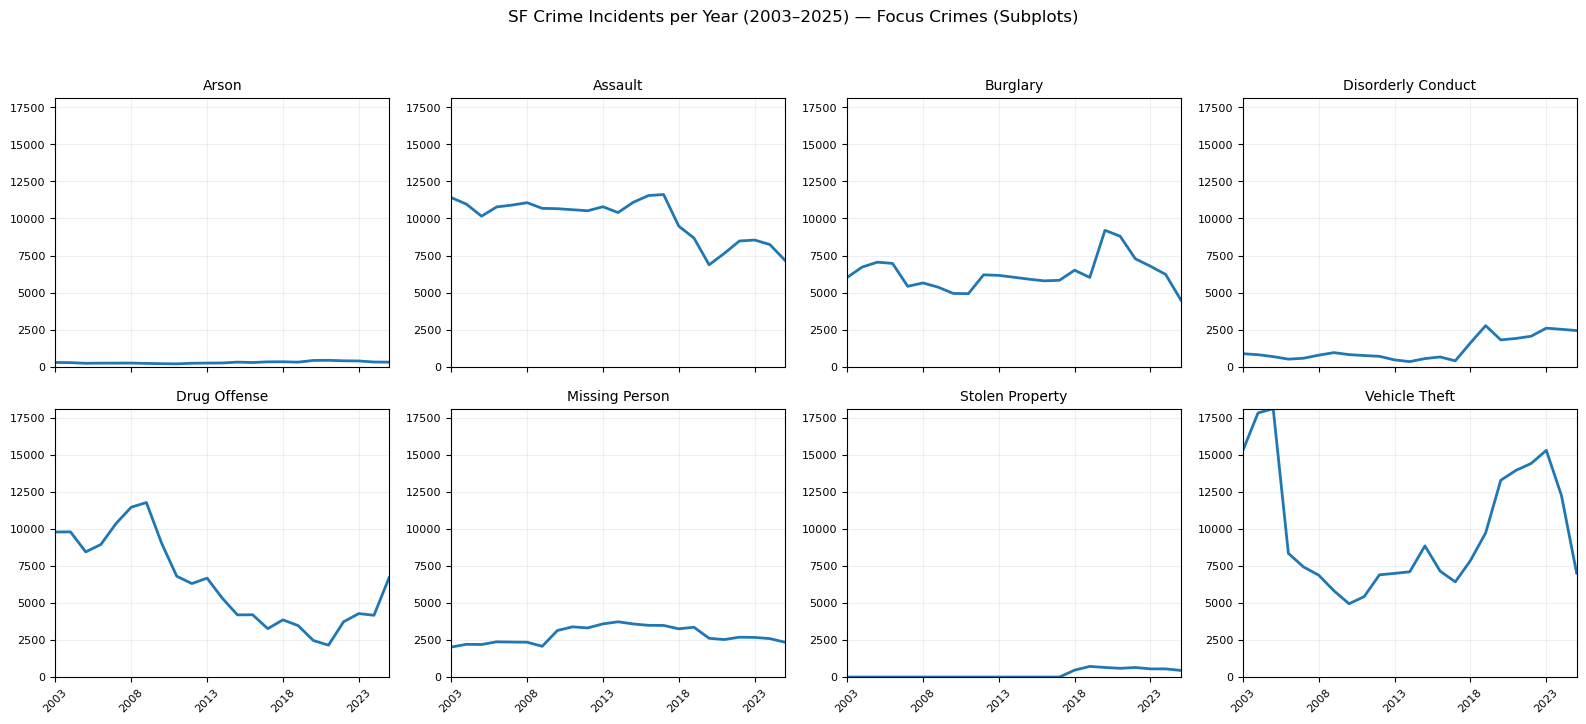

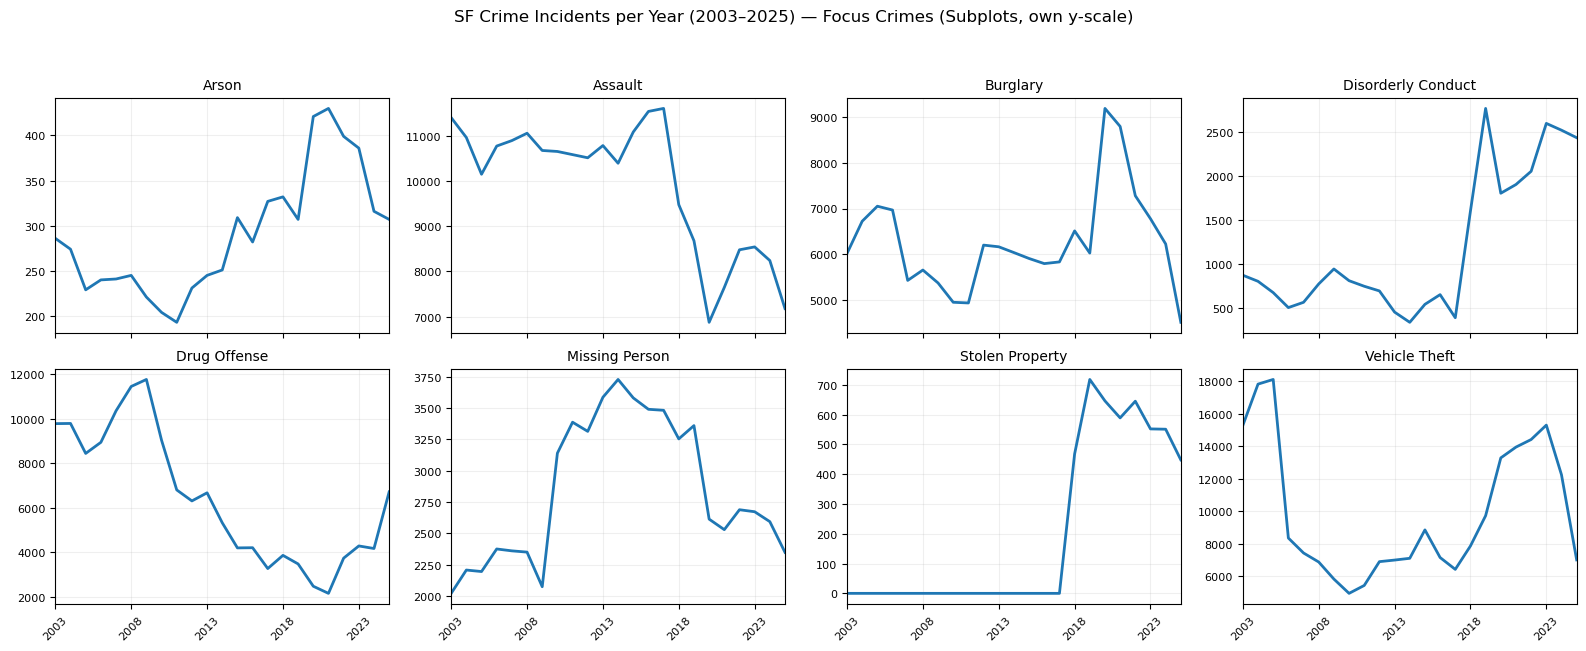

In [64]:
pretty = {
  "assault":"Assault",
  "burglary":"Burglary",
  "vehicle theft":"Vehicle Theft",
  "drug offense":"Drug Offense",
  "missing person":"Missing Person",
  "disorderly conduct":"Disorderly Conduct",
  "stolen property":"Stolen Property",
  "arson":"Arson",
}

# 1) combined plot 
plt.figure(figsize=(12,6))
for crime in wide.columns:
    plt.plot(wide.index, wide[crime], linewidth=2, label=pretty.get(crime, crime))

plt.title("SF Crime Incidents per Year (2003–2025) — Focus Crimes")
plt.xlabel("Year")
plt.ylabel("Number of incidents")
plt.xticks(range(2003, 2026, 2))
plt.ylim(bottom=0)
plt.grid(alpha=0.3)
plt.legend(title="Crime category", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

# 2) Add subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
axes = axes.flatten()

ymax = wide.max().max()

for ax, crime in zip(axes, wide.columns):
    ax.plot(wide.index, wide[crime], linewidth=2)
    ax.set_title(pretty.get(crime, crime), fontsize=10)
    ax.grid(alpha=0.2)
    ax.set_xlim(2003, 2025)
    ax.set_ylim(0, ymax)

# meaningful ticks
for ax in axes:
    ax.set_xticks(range(2003, 2026, 5))     # fewer ticks than every 4
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("SF Crime Incidents per Year (2003–2025) — Focus Crimes (Subplots)", y=1.03)
fig.tight_layout(pad=1.2)
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
axes = axes.flatten()

for ax, crime in zip(axes, wide.columns):
    ax.plot(wide.index, wide[crime], linewidth=2)
    ax.set_title(pretty.get(crime, crime), fontsize=10)
    ax.grid(alpha=0.2)
    ax.set_xlim(2003, 2025)

for ax in axes:
    ax.set_xticks(range(2003, 2026, 5))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("SF Crime Incidents per Year (2003–2025) — Focus Crimes (Subplots, own y-scale)", y=1.03)
fig.tight_layout(pad=1.2)
fig.subplots_adjust(bottom=0.18)
plt.show()

<small><em>Figure: Yearly incident counts for the selected focus crimes in San Francisco (2003–2025).</em></small>

**Note on the subplot figures**

I included two versions of the subplots: one where all crimes share the same y-axis scale (so magnitudes can be compared directly), and one where each subplot has its own y-axis scale (so smaller categories like arson are still readable and their patterns are visible).

In [65]:
yoy = wide.diff()  # change vs previous year

top_changes = (
    yoy.stack()
       .reset_index()
       .rename(columns={"level_1": "crime", 0: "change"})
       .assign(abs_change=lambda d: d["change"].abs())
       .sort_values("abs_change", ascending=False)
)

top_changes.head(10)

,Incident Year,Incident Category,change,abs_change
23,2006,vehicle theft,-9756.0,9756.0
175,2025,vehicle theft,-5234.0,5234.0
135,2020,vehicle theft,3556.0,3556.0
130,2020,burglary,3176.0,3176.0
167,2024,vehicle theft,-3056.0,3056.0
52,2010,drug offense,-2735.0,2735.0
172,2025,drug offense,2549.0,2549.0
7,2004,vehicle theft,2540.0,2540.0
60,2011,drug offense,-2234.0,2234.0
113,2018,assault,-2133.0,2133.0


In [66]:
# Pick the two features we will discuss 
features = [
    (2006, "vehicle theft"),
    (2020, "burglary"),
]

for year, crime in features:
    prev = wide.loc[year-1, crime]
    cur  = wide.loc[year, crime]
    delta = cur - prev
    print(f"{crime} {year-1}->{year}: {prev:.0f} -> {cur:.0f} (Δ={delta:+.0f})")

vehicle theft 2005->2006: 18103 -> 8347 (Δ=-9756)
burglary 2019->2020: 6022 -> 9198 (Δ=+3176)


**Assignment 1.1 — Temporal Overview**

***Question:***  
Plot the total number of incidents per year (2003–2025) for each Personal Focus Crime, and comment on at least two notable features with possible explanations.

**How I selected “notable features”**

To pick the two features to comment on (spikes/drops), I computed year-to-year changes for each focus crime using `wide.diff()`. Then I sorted by the largest absolute changes to see which years stand out the most. I use those years as the “notable features” below, and I cross-check them visually in the plots.

**Notable feature 1 — sharp drop in Vehicle Theft in 2006**  
Vehicle theft shows the largest sudden change in the whole period: from **2005 to 2006** it drops by about **9,756 incidents** (from **18,103** in 2005 to **8,347** in 2006). This is also very visible in both the combined plot and the vehicle-theft subplot.

***Possible explanation (my guess):*** this could be related to changes that made cars harder to steal (better built-in security over time) and/or improved prevention/policing focused on auto theft, which might cause a faster drop compared with other categories.

**Notable feature 2 — COVID-era spike around 2020 (example: Burglary)**  
Around **2020** (COVID period), some categories show unusually strong increases compared with nearby years. For example, **burglary increases by about 3,176 incidents from 2019 to 2020** (from **6,022** in 2019 to **9,198** in 2020). This stands out compared to the smoother changes in the years before.

***Possible explanation (my guess):*** COVID changed daily routines and where people spent time, which can affect opportunities for certain crimes and also how/when incidents are observed and reported.

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

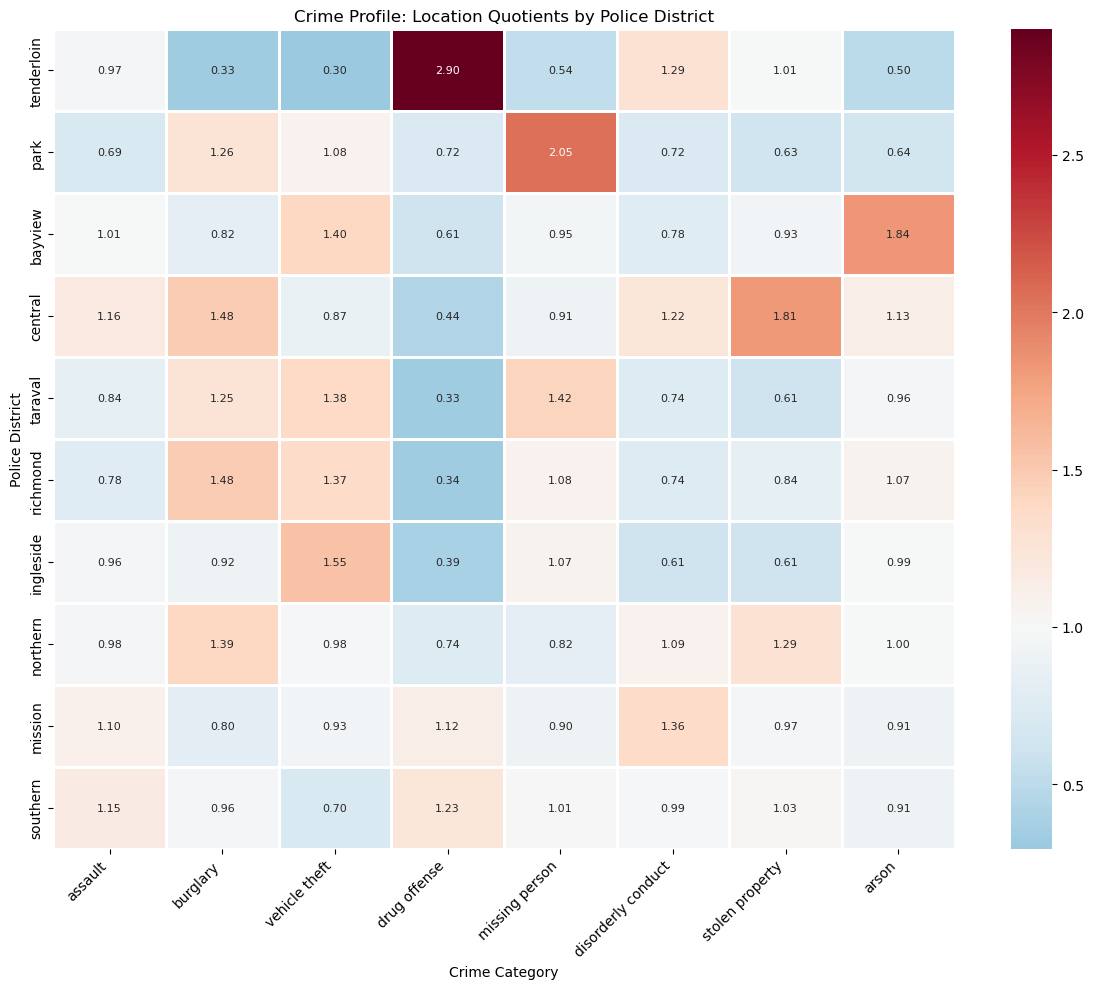

In [67]:
df_district = df_focus[df_focus["Police District"].str.lower() != "out of sf"].copy()
# P(crime)
p_crime = df_district["Incident Category"].value_counts(normalize=True)

# P(crime|district)
category_group = df_district.groupby(["Police District"])
p_crime_district = category_group["Incident Category"].value_counts(normalize=True)

# crime_profile = p_crime_district / p_crime
crime_profile = (
    p_crime_district
            .unstack(fill_value=0)
            .div(p_crime, axis='columns')
            .fillna(0)
)

crime_profile = crime_profile[focus_crimes]  
row_score = (crime_profile - 1).abs().max(axis=1)
crime_profile_sorted = crime_profile.loc[row_score.sort_values(ascending=False).index]

plt.figure(figsize=(12, 10))
sns.heatmap(
    crime_profile_sorted,
    annot=True,
    annot_kws={"size":8},
    fmt=".2f",
    cmap="RdBu_r",          # red = high, blue = low
    center=1,               # center at 1 (neutral)
    linewidths=1,
)
plt.title("Crime Profile: Location Quotients by Police District")
plt.xlabel("Crime Category")
plt.ylabel("Police District")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Assignment 1.2 — Crime Profiles by Police District**

***Question:*** Compute the location quotient for each crime and district:

$$
r(\text{crime}, \text{district}) \;=\; \frac{P(\text{crime}\mid \text{district})}{P(\text{crime})}.
$$

Visualize the ratios and discuss one district that stands out.

**Crime profiles by police district (location quotients)**

For each police district, I computed a *crime profile* using the ratio

$$
r(\text{crime}, \text{district}) \;=\; \frac{P(\text{crime}\mid \text{district})}{P(\text{crime})}.
$$ 

Here, $P(\text{crime}\mid \text{district})$ is the fraction of incidents **within that district** that belong to a given crime category, and $P(\text{crime})$ is the **city-wide** fraction of incidents in that category.  
So $r>1$ means the crime is **over-represented** in that district (it makes up a larger share than the city average), while $r<1$ means it is **under-represented**.

To make comparison easy across both districts and crime types, I visualized the ratios as a **heatmap** centered at 1. I also sorted districts by how “unusual” their profile is (largest deviation from 1), so the most distinctive districts appear at the top.

**District that stands out: Tenderloin.**  
Tenderloin stands out because **drug offenses are strongly over-represented** (ratio ≈ **2.94**), meaning drug offenses make up a much larger share of incidents there than in San Francisco overall. At the same time, some categories are clearly under-represented (e.g., **vehicle theft ≈ 0.28** and **burglary ≈ 0.34**), meaning those crimes form a smaller share of Tenderloin’s incidents than the city baseline.

**Possible explanation (my guess):** Tenderloin is a very dense area with heavy foot traffic and lots of “street life” (restaurants, bars/nightlife, transit connections). This could create more opportunities for street-level drug activity and also make drug-related incidents more visible/recorded. Differences in policing focus and reporting behavior across neighborhoods might also contribute.  
*Small fun fact:* the heatmap makes it feel like “if you want to see an extreme value, Tenderloin will deliver” — especially for drug offenses.

---
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

### Part A

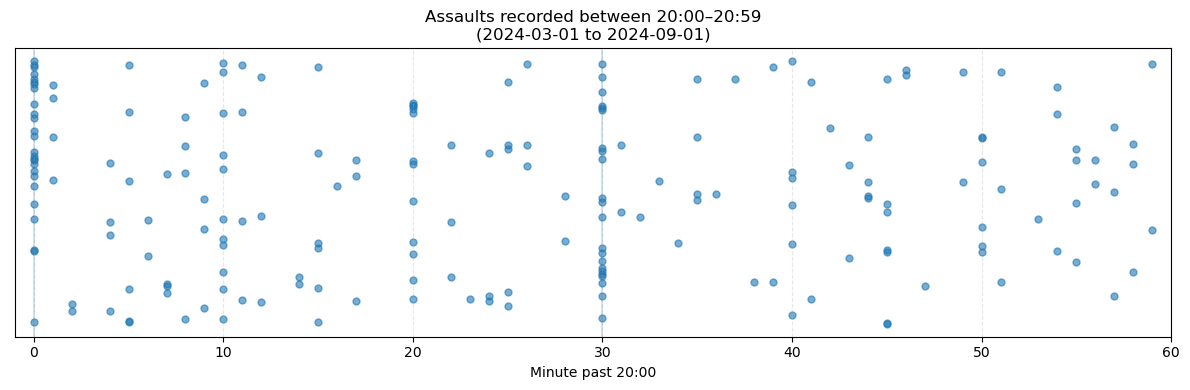

Counts at rounded minutes: {0: 26, 10: 11, 20: 12, 30: 22}


In [68]:
df_focus["Incident Datetime"] = pd.to_datetime(df_focus["Incident Datetime"])

category_group = df_focus.groupby(["Incident Category"])
assault = category_group.get_group("assault")

start_date = pd.Timestamp('2024-03-01 00:00:00')
end_date   = pd.Timestamp('2024-09-01 00:00:00')

# Filter
assault = assault[
    (assault['Incident Datetime'] >= start_date) &
    (assault['Incident Datetime'] < end_date)
].copy()

hour_of_interest = 20

assault_one_hour = assault[assault['Incident Datetime'].dt.hour == hour_of_interest].copy()
assault_one_hour['Minute'] = assault_one_hour['Incident Datetime'].dt.minute

assault_one_hour["jitter_y"] = np.random.uniform(-0.4, 0.4, size=len(assault_one_hour))

plt.figure(figsize=(12, 4))
plt.scatter(
    assault_one_hour["Minute"],
    assault_one_hour["jitter_y"],
    alpha=0.6,
    s=25
)

plt.title(
    f"Assaults recorded between {hour_of_interest:02d}:00–{hour_of_interest:02d}:59\n"
    f"({start_date.date()} to {end_date.date()})"
)
plt.xlabel(f"Minute past {hour_of_interest:02d}:00")
plt.yticks([])                 
plt.grid(axis="x", alpha=0.3, linestyle="--")
plt.xlim(-1, 60)
plt.axvline(0, alpha=0.2)
plt.axvline(30, alpha=0.2)
plt.tight_layout()
plt.show()

vc = assault_one_hour["Minute"].value_counts()
print("Counts at rounded minutes:", {m: int(vc.get(m, 0)) for m in [0, 10, 20, 30]})

**Assignment 1.3 — Part A (Jitter plot)**

***Question:*** Create a jitter plot of incident times within a single hour (x-axis = minute, vertical jitter), and comment on what it reveals about timestamp precision.

In the jitter plot (assaults between 20:00–20:59), incidents are clearly **not** evenly distributed across minutes.  
Instead, they cluster at “round” times: the most common recorded minutes are **0 (26 cases)** and **30 (22 cases)**, followed by **20 (12)** and **10 (11)**.  

This suggests that incident times are often **rounded** when entered (e.g., to the nearest 10 or 30 minutes), so the timestamps do not always have true minute-level precision.

### Part B

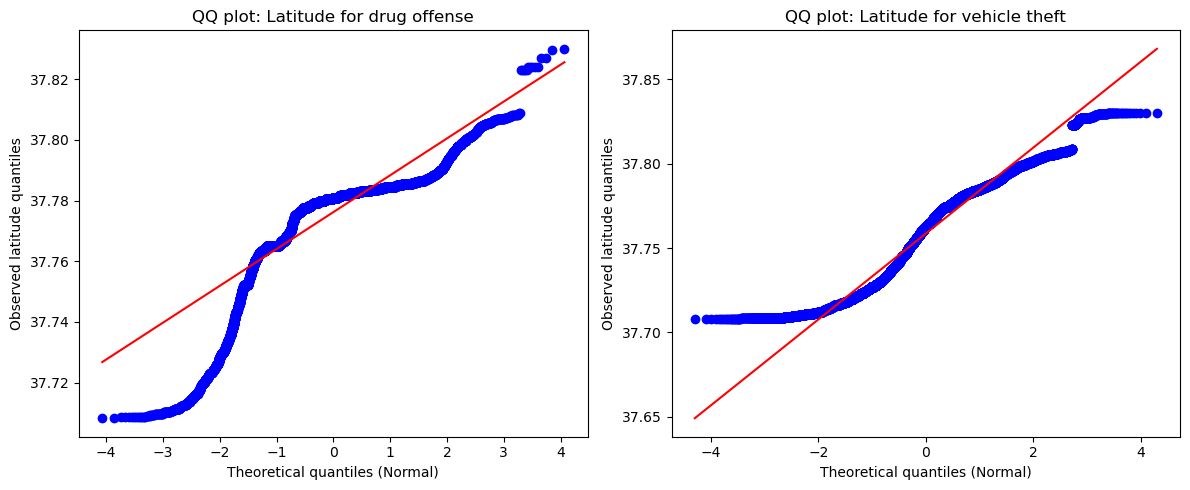

drug offense n = 29097
vehicle theft n = 79893


In [69]:
# choose two crime types 
crime1 = "drug offense"
crime2 = "vehicle theft"

# latitude column name
LAT_COL = "Latitude"

lat1 = df_focus.loc[df_focus["Incident Category"] == crime1, LAT_COL].dropna()
lat2 = df_focus.loc[df_focus["Incident Category"] == crime2, LAT_COL].dropna()

# keep only plausible SF latitudes (prevents bad outliers ruining the QQ plot)
lat1 = lat1[(lat1 > 37.6) & (lat1 < 37.85)]
lat2 = lat2[(lat2 > 37.6) & (lat2 < 37.85)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(lat1, dist="norm", plot=axes[0])
axes[0].set_title(f"QQ plot: Latitude for {crime1}")
axes[0].set_xlabel("Theoretical quantiles (Normal)")
axes[0].set_ylabel("Observed latitude quantiles")

stats.probplot(lat2, dist="norm", plot=axes[1])
axes[1].set_title(f"QQ plot: Latitude for {crime2}")
axes[1].set_xlabel("Theoretical quantiles (Normal)")
axes[1].set_ylabel("Observed latitude quantiles")

plt.tight_layout()
plt.show()

print(f"{crime1} n = {len(lat1)}")
print(f"{crime2} n = {len(lat2)}")

**Assignment 1.3 — Part B (Probability / QQ plot)**

***Question:*** Create QQ plots for the latitude distribution of two crime types and explain what deviations from a Normal reference distribution imply about spatial clustering in SF.

### QQ plots (latitude)

These QQ plots compare the observed latitude quantiles to a **Normal (Gaussian)** reference distribution (`dist="norm"`).

If the points fell closely on the straight red line, it would mean the latitude values are approximately normal (i.e., spread like a bell curve in the north–south direction). In both crime types, the points clearly bend away from the line, especially in the tails, so the latitude distributions are **not normal**.

This deviation makes sense geographically: crime locations are constrained by the shape of San Francisco and tend to be **clustered** in specific areas rather than spread smoothly across latitudes. The drug offense plot shows stronger curvature/step-like behavior, suggesting a more concentrated set of latitude bands (stronger hotspot structure), while vehicle theft looks somewhat more spread out but still clearly non-normal.  
(Drug offense n = 29,097; vehicle theft n = 79,893.)

### Part C

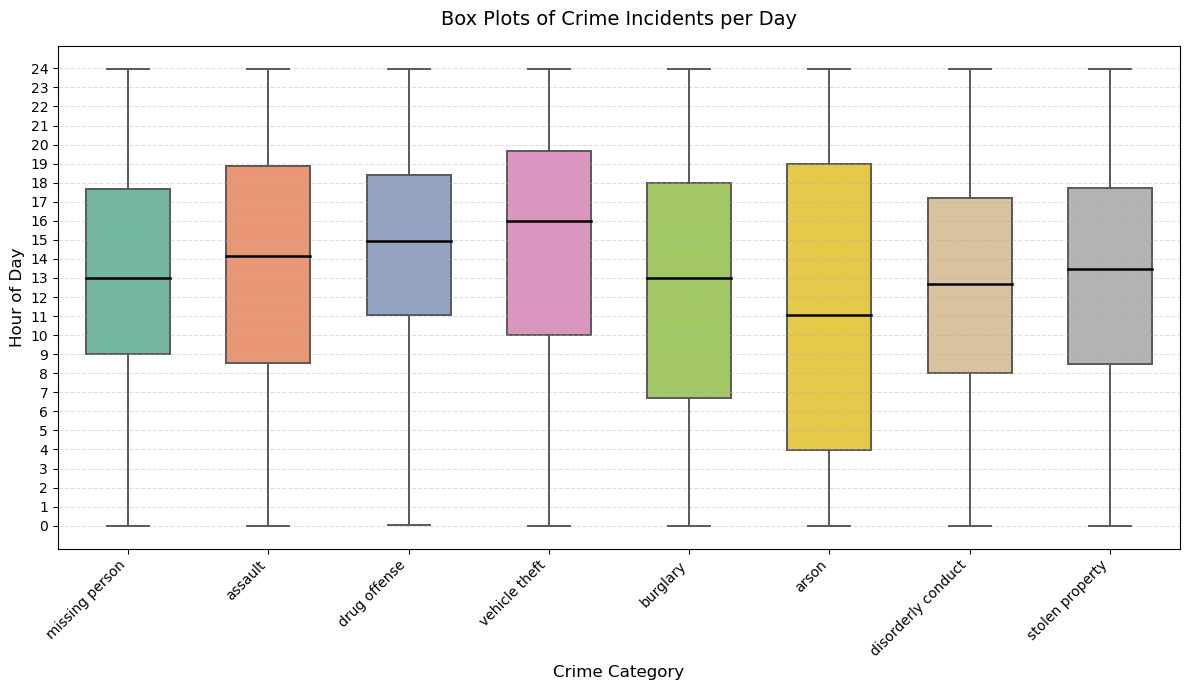

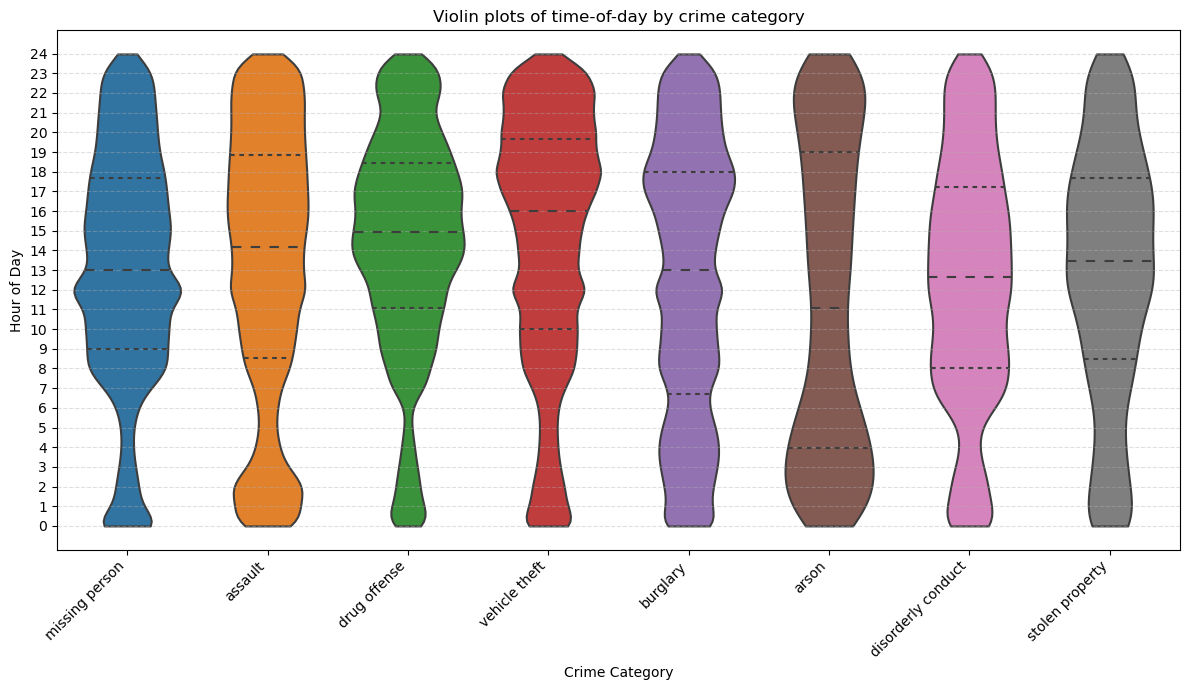

In [70]:
df_focus['Hour'] = (
    df_focus['Incident Datetime'].dt.hour +
    df_focus['Incident Datetime'].dt.minute / 60 +
    df_focus['Incident Datetime'].dt.second / 3600
)

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_focus,
    x='Incident Category',
    y='Hour',
    palette='Set2',
    width=0.6,
    linewidth=1.4,
    showfliers=False,
    whis=1.5,
    medianprops=dict(color='black', linewidth=1.8),
)

plt.title("Box Plots of Crime Incidents per Day", fontsize=14, pad=15)
plt.xlabel("Crime Category", fontsize=12)
plt.ylabel("Hour of Day", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(range(0, 25))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.violinplot(
    data=df_focus,
    x="Incident Category",
    y="Hour",
    inner="quartile",
    cut=0
)
plt.title("Violin plots of time-of-day by crime category")
plt.xlabel("Crime Category")
plt.ylabel("Hour of Day")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(range(0, 25))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Assignment 1.3 — Part C (Time-of-day distributions)**

***Question:*** Extract time-of-day for each focus crime and compare their distributions using box plots. Comment on day vs night patterns, and explain what goes wrong with midnight wrap-around. Optionally, use another plot type and explain what it adds.

### Part C — Time-of-day patterns (box plot + violin plot)

From the box plots, the focus crimes do not have identical time-of-day patterns. Most categories have medians in the **daytime / early evening**, but both the median and the IQR (middle 50%) differ across crimes.

In particular, **vehicle theft** and **drug offense** are shifted later than several other categories (higher medians and more mass in the afternoon/evening). **Disorderly conduct** looks more concentrated around daytime/early evening hours, which fits with incidents happening when public/commercial areas are active. **Burglary** has a wider spread across the day, suggesting it occurs in many different time windows rather than being tightly concentrated.

**Wrap-around issue:** time-of-day is *circular*, but a box plot treats it as linear from 0 to 24. This can distort late-night behavior: events around **23:55** and **00:05** are close in real life, but they appear far apart on the y-axis. As a result, late-night crimes can look artificially more spread out, and the median/IQR can become harder to interpret.

The violin plots add extra information by showing the **density/shape** of the distribution. While the box plot summarizes with quartiles, the violin plot shows where the data is most concentrated (thicker regions). For some crimes, the violin shape suggests more than one “busy period” during the day.

<small><em>Fun takeaway:</em> seeing that some categories shift later in the day, I’m suddenly more motivated to not leave my car in sketchy places late at night .</small>

---
## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots? Let's find out.

*Draws from*: Week 4, Exercise 2.2.

Use your **most common Personal Focus Crime** (by total incident count) for this exercise.

> * **Step 1**: Divide San Francisco into a grid of approximately $100\text{m} \times 100\text{m}$ cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.
>     * **Hint**: `np.histogram2d` works well here. Focus on points within the SF peninsula; filter out geographic outliers.
> * **Step 2**: Count the number of incidents of your chosen crime in each grid cell (use all years of data).
> * **Step 3**: Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.
> * **Step 4**: Plot $(k+1)$ vs $N(k)$ on **linear axes**.
> * **Step 5**: Plot $(k+1)$ vs $N(k)$ on **loglog axes**.
> * **Step 6**: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?
> * **Step 7**: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?

In [71]:
CRIME_COL = "Incident Category"
LAT_COL = "Latitude"
LON_COL = "Longitude"

crime_counts = df_focus[CRIME_COL].value_counts()
crime_counts.loc[focus_crimes].sort_values(ascending=False)

crime_name = crime_counts.loc[focus_crimes].idxmax()

crime_df = df_focus[df_focus[CRIME_COL] == crime_name].dropna(subset=[LAT_COL, LON_COL])

crime_df = crime_df[
    (crime_df[LAT_COL].between(37.70, 37.83)) &
    (crime_df[LON_COL].between(-122.52, -122.35))
].copy()


In [72]:
crime_df = df_focus[df_focus[CRIME_COL] == crime_name].copy()

crime_df = crime_df.dropna(subset=[LAT_COL, LON_COL])

# rough SF bounding box (filters out geographic outliers)
crime_df = crime_df[
    (crime_df[LAT_COL].between(37.70, 37.83)) &
    (crime_df[LON_COL].between(-122.52, -122.35))
].copy()

len(crime_df)

61073

In [73]:
lat_step = 100 / 111_000
lon_step = 100 / (111_000 * np.cos(np.deg2rad(37.77)))

lat_min, lat_max = crime_df[LAT_COL].min(), crime_df[LAT_COL].max()
lon_min, lon_max = crime_df[LON_COL].min(), crime_df[LON_COL].max()

lat_bins = np.arange(lat_min, lat_max + lat_step, lat_step)
lon_bins = np.arange(lon_min, lon_max + lon_step, lon_step)

len(lat_bins), len(lon_bins)

(137, 127)

In [74]:
H, yedges, xedges = np.histogram2d(
    crime_df[LAT_COL].to_numpy(),
    crime_df[LON_COL].to_numpy(),
    bins=[lat_bins, lon_bins]
)

# H is counts per cell
H.shape, H.sum()

((136, 126), 61073.0)

In [75]:
cell_counts = H.astype(int).ravel()

max_k = cell_counts.max()
Nk = np.bincount(cell_counts)  # Nk[k] = number of cells with count k

k = np.arange(len(Nk))      
len(Nk), max_k

(661, 660)

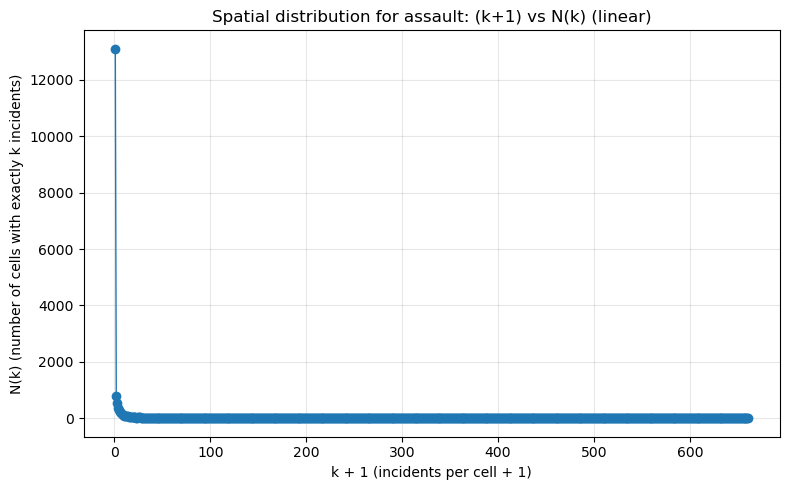

In [76]:
x = k + 1
y = Nk

plt.figure(figsize=(8,5))
plt.plot(x, y, marker="o", linewidth=1)
plt.title(f"Spatial distribution for {crime_name}: (k+1) vs N(k) (linear)")
plt.xlabel("k + 1 (incidents per cell + 1)")
plt.ylabel("N(k) (number of cells with exactly k incidents)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

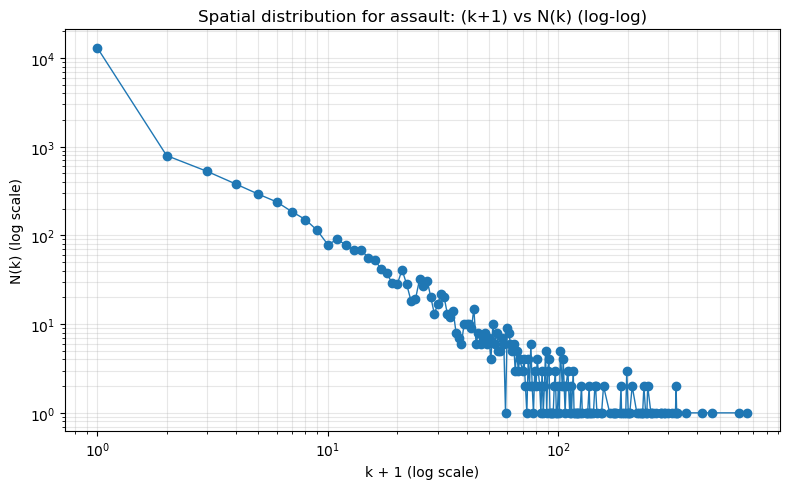

In [77]:
mask = y > 0

plt.figure(figsize=(8,5))
plt.plot(x[mask], y[mask], marker="o", linewidth=1)
plt.xscale("log")
plt.yscale("log")
plt.title(f"Spatial distribution for {crime_name}: (k+1) vs N(k) (log-log)")
plt.xlabel("k + 1 (log scale)")
plt.ylabel("N(k) (log scale)")
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

**Assignment 1.4 — Spatial Power Law**

**Question:** Using the most common focus crime, divide SF into ~100m×100m grid cells, count incidents per cell, compute $N(k)$ (cells with exactly $k$ incidents), plot $(k+1)$ vs $N(k)$ on linear and log–log axes, and discuss whether the pattern is power-law-like and what that implies for neighborhood averages.

### Spatial power law (Assault)

**Chosen crime:** Assault is the most common focus crime in the dataset (≈ 228k incidents overall), so I used it for the grid analysis. After filtering to plausible SF peninsula coordinates, I kept **61,073** assault incidents and divided the city into an approx **100m × 100m** grid (about **137 × 127** cells).

**What the linear plot shows:** The (k+1) vs N(k) plot is extremely skewed: most grid cells have **very few incidents**, while only a small number of cells have **many incidents**. In other words, assaults are not spread evenly — they are concentrated in a limited set of hotspots.

**Log–log plot and power-law question:** On the log–log plot, the points form an approximately straight downward trend for a range of k values (especially for small-to-mid k), which is what you would expect from a **power-law-like** relationship (a power law becomes roughly linear in log–log space). The curve becomes noisier and less straight in the far right tail (large k), which makes sense because very high-count cells are rare (small N(k)), so randomness becomes stronger there. Overall, the log–log shape supports the idea that the spatial distribution is *roughly* power-law / heavy-tailed rather than “uniform”.

**What this implies for neighborhood averages:** Because a small number of cells account for a lot of incidents, “average crime per block” can be misleading. The “typical” grid cell has little or no assault, while a few hotspot cells dominate the totals. So neighborhood-level averages can hide important structure: two areas could have the same average but very different reality (one evenly spread vs one driven by a couple of hotspot intersections). In practice, this means hotspot maps / distributions are often more informative than a single average.

---
## Assignment 1.5: Regression and Correlation

Which of your Personal Focus Crimes share the most similar weekly rhythm — and which are completely out of sync?

*Draws from*: Week 4, Exercises 3.1, 3.2, and 3.3.

Select **at least 4** of your Personal Focus Crimes for this exercise. More is fine - if you want to be closer to the actual weekly exercise.

> * For each selected crime type, compute the total number of incidents for each of the **168 hours of the week** (i.e., Monday 00:00–01:00, Monday 01:00–02:00, ..., Sunday 23:00–00:00). Each crime type will give you a vector of 168 values.
>
> * **Scatterplot matrix**: Create a grid of pairwise scatterplots — one panel per pair of crime types, with one crime on each axis and each of the 168 hours as a point. Label each panel clearly with the two crime types being compared.
>
> * **Linear regression**: Using the closed-form equations from Week 4 (not a library), fit a regression line $y = ax + b$ to each pair and add it to the relevant panel:
>   $$a = \frac{\sum_i x_i y_i - N\langle x\rangle\langle y\rangle}{\sum_i x_i^2 - N\langle x\rangle^2}, \qquad b = \langle y \rangle - a\langle x \rangle$$
>
> * **$R^2$**: Compute $R^2$ for each pair and display the value on each panel. 
>
> * Looking at your results: which pair of crimes is **most correlated**? Which is **least correlated**? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?

In [78]:
# Self-implemented helpers 
def mysum(arr):
    s = 0.0
    for v in arr:
        s += float(v)
    return s

def mean(arr):
    return mysum(arr) / len(arr)

def linear_regression(x, y):
    # ensure numpy arrays
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    x_mean = mean(x)
    y_mean = mean(y)

    denom = mysum(x * x) - n * (x_mean ** 2)
    if denom == 0:
        return 0.0, y_mean

    a = (mysum(x * y) - n * x_mean * y_mean) / denom
    b = y_mean - a * x_mean
    return a, b

def r_squared(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    y_mean = mean(y)
    a, b = linear_regression(x, y)

    ss_res = mysum((y - (a * x + b)) ** 2)
    ss_tot = mysum((y - y_mean) ** 2)

    if ss_tot == 0:
        return 1.0

    return 1 - (ss_res / ss_tot)

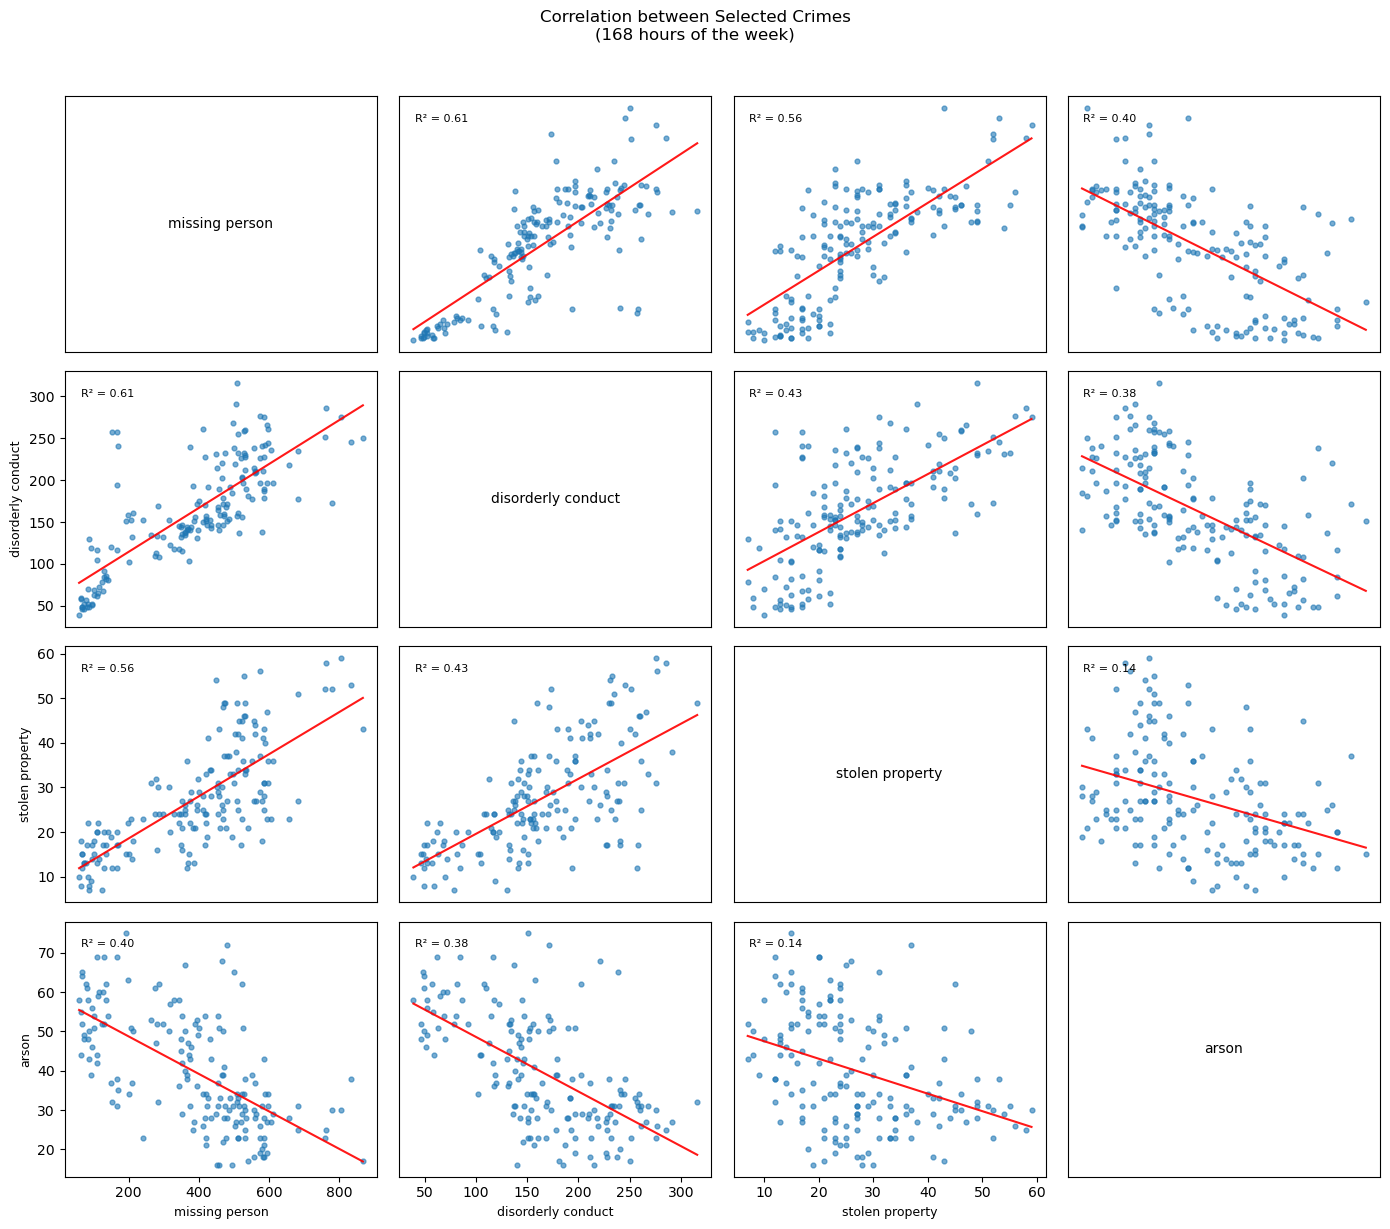

In [79]:
selected_crimes = [
  "Missing Person",
  "Disorderly Conduct",
  "Stolen Property",
  "Arson",
]
selected_crimes = [c.lower() for c in selected_crimes]

df_selected = df_focus[df_focus["Incident Category"].isin(selected_crimes)].copy()
df_selected["Weekday"] = df_selected["Incident Datetime"].dt.weekday
df_selected["Hour"] = df_selected["Incident Datetime"].dt.hour
df_selected["Week Hour"] = df_selected["Weekday"] * 24 + df_selected["Hour"]

counts = (
    df_selected.groupby(["Week Hour", "Incident Category"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(168), fill_value=0)
)

n_crimes = len(selected_crimes)
fig, axes = plt.subplots(nrows=n_crimes, ncols=n_crimes, figsize=(14, 12))

for row in range(n_crimes):          # y-axis crime
    for col in range(n_crimes):      # x-axis crime
        ax = axes[row, col]

        x = counts[selected_crimes[col]].to_numpy()
        y = counts[selected_crimes[row]].to_numpy()


        if row == col:
            ax.text(0.5, 0.5, selected_crimes[col], ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        ax.scatter(x, y, s=12, alpha=0.6)

        # regression line + R²
        a, b = linear_regression(x, y)
        r2 = r_squared(x, y)

        x_line = np.array([x.min(), x.max()])
        ax.plot(x_line, a * x_line + b, color="red", lw=1.5, alpha=0.9)

        ax.text(0.05, 0.90, f"R² = {r2:.2f}", fontsize=8, transform=ax.transAxes)

        if row == n_crimes - 1:
            ax.set_xlabel(selected_crimes[col], fontsize=9)
        else:
            ax.set_xticks([])

        if col == 0:
            ax.set_ylabel(selected_crimes[row], fontsize=9)
        else:
            ax.set_yticks([])

plt.suptitle("Correlation between Selected Crimes\n(168 hours of the week)", y=1.02)
plt.tight_layout()
plt.show()

In [80]:
r2_pairs = []

for i in range(n_crimes):
    for j in range(i+1, n_crimes):  # only unique pairs
        x = counts[selected_crimes[i]].to_numpy()
        y = counts[selected_crimes[j]].to_numpy()
        r2 = r_squared(x, y)
        r2_pairs.append((r2, selected_crimes[i], selected_crimes[j]))

r2_pairs_sorted = sorted(r2_pairs, key=lambda t: t[0], reverse=True)

print("Most correlated:", r2_pairs_sorted[0])
print("Least correlated:", r2_pairs_sorted[-1])

Most correlated: (0.6132359075158514, 'missing person', 'disorderly conduct')
Least correlated: (0.13835583341697444, 'stolen property', 'arson')


**Regression and correlation (168 hours of the week)**

I selected four focus crimes (**missing person, disorderly conduct, stolen property, arson**) and, for each crime, built a 168-length vector counting incidents in each **hour-of-week** (Monday 00:00–01:00, …, Sunday 23:00–00:00).  
I then made a scatterplot matrix where each point corresponds to one of the 168 hours, and for each crime pair I fit a line using the **closed-form** regression equations from Week 4 and displayed the resulting **$R^2$**.

**Most correlated pair:** **missing person vs disorderly conduct** with $R^2 \approx 0.61$.  
This suggests these two crimes have a fairly similar weekly rhythm: when one is high during certain hours of the week, the other tends to be high as well. A possible reason is that both are connected to “people activity” patterns (more people out at certain times, weekends/evenings, etc.), so their counts rise and fall together.

**Least correlated pair:** **stolen property vs arson** with $R^2 \approx 0.14$.  
Here the scatter is much more diffuse, meaning their week-to-week timing patterns don’t line up well. This matches the idea that these crime types may be driven by different situations and opportunities, so their peaks do not occur at the same hours.

Overall, the results make sense to me: some crimes appear tied to shared human routines (leading to similar rhythms), while others depend on different mechanisms and therefore look “out of sync” across the 168 hours.

**Conclusion**


Overall, this assignment convinced us that SF crime patterns are structured in time and space: trends change over years, districts have distinct profiles, and incidents are spatially concentrated in hotspots rather than evenly spread. The distribution plots also highlighted limitations of the data (like rounded times and circular time-of-day). Finally, the 168-hour analysis showed that some crime types move together over the week, while others do not.

<small><em>Fun note:</em> this notebook taught me two things: SF crime has patterns… and I should probably pay more attention to where/when I’m walking (and where I park).</small>

## Contributions

- **Tobias Nicolai Frederiksen (s235086):** Assignment **1.2** (Crime Profiles by Police District), Assignment **1.3 Parts A & C** (Jitter plot + Time-of-day distributions), and Assignment **1.5** (Regression and Correlation).

- **Yasmine Bouattour (s251706):** Assignment **1.1** (Temporal Overview), Assignment **1.3 Part B** (QQ plots), and Assignment **1.4** (Spatial Power Law). Also handled general polishing/structuring of all the sections (plot formatting, captions, and markdown clarity where needed).